# 进阶实践项目 05 参考答案：插值、图像分支、融合残差与聚合一致性

本答案比较三条路线：低分辨率双线性基线、仅 H&E 的图像网络、H&E 与低分辨率表达的融合残差网络。目的不是寻找最高相关性，而是通过消融判断信息来自哪里，并检查预测重新聚合后是否与观测冲突。


> **实践定位**
>
> 这不是短时间代码竞赛，也不是以最高分数决定完成度的作业。可以只完成数据核对、基线、一个消融实验或一段严谨的失败分析。问题定义、文献依据、方法选择、验证设计、错误解释和下一步实验，重要性高于单一性能数值。
>
> 最终提交由两部分组成：当前 Notebook，以及一份设计报告。设计报告不是代码说明书，而是研究方案说明。参考答案只展示一种能够运行的方案，不代表唯一正确答案，也不意味着其中的模型一定最适合你的目标。

**参考答案不是唯一正确答案。** 其他方案只要问题定义、数据处理、验证和解释合理，同样可以成立。

## 对应题目 1：环境、真实数据和 shape 统一

参考答案接受 `he/lr/hr/split` NPZ。若没有数据则使用明确标记的模拟数据。代码把 H&E 统一为通道优先，并把表达补成 `[N,C,H,W]`。


In [1]:
from pathlib import Path
import json
import numpy as np,matplotlib.pyplot as plt
import torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
SEED=42;np.random.seed(SEED);torch.manual_seed(SEED);DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu');QUICK_MODE=True
OUT=Path('/kaggle/working') if Path('/kaggle').exists() else Path('outputs_adv05');OUT.mkdir(exist_ok=True)

def load_data():
 files=[]
 for root in [Path('/kaggle/input'),Path('/mnt/data')]:
  if root.exists():files+=list(root.glob('**/*.npz'))
 for f in files:
  d=np.load(f,allow_pickle=True)
  if {'he','lr','hr','split'}.issubset(d.files): return d['he'].astype('float32'),d['lr'].astype('float32'),d['hr'].astype('float32'),d['split'].astype(str),'real'
 n=60;H=32;r=np.random.default_rng(SEED);he=r.random((n,3,H,H),dtype=np.float32);hr=np.zeros((n,1,H,H),np.float32);yy,xx=np.mgrid[:H,:H]
 for i in range(n):hr[i,0]=np.clip(.55*he[i,0]+.25*he[i,1]+.35*np.exp(-((xx-r.uniform(8,24))**2+(yy-r.uniform(8,24))**2)/r.uniform(20,70)),0,1)
 lr=hr.reshape(n,1,4,8,4,8).sum((3,5));split=np.array(['train']*40+['val']*10+['test']*10);return he,lr,hr,split,'demo'
he,lr,hr,split,mode=load_data()
if he.ndim==4 and he.shape[-1] in (1,3):he=np.moveaxis(he,-1,1)
if lr.ndim==3:lr=lr[:,None]
if hr.ndim==3:hr=hr[:,None]
print(mode,he.shape,lr.shape,hr.shape,np.unique(split,return_counts=True))


demo (60, 3, 32, 32) (60, 1, 4, 4) (60, 1, 32, 32) (array(['test', 'train', 'val'], dtype='<U5'), array([10, 40, 10]))


## 对应题目 2：低分辨率基线与观测定义

当前数据把 `lr` 定义为高分辨率块内的总和，因此上采样后需要除以面积倍率，得到均匀分配的密度基线。若你的 `lr` 是平均表达，则不应再除面积。该定义必须在报告中明确。


In [2]:
def up_lr(a,H,W):return F.interpolate(torch.tensor(a),size=(H,W),mode='bilinear',align_corners=False).numpy()
scale=(hr.shape[-2]//lr.shape[-2])*(hr.shape[-1]//lr.shape[-1]);base=up_lr(lr,hr.shape[-2],hr.shape[-1])/scale

def aggregate(x,lh,lw):
 B,C,H,W=x.shape;return x.reshape(B,C,lh,H//lh,lw,W//lw).sum((3,5))
print('truth aggregation error',float(np.abs(aggregate(torch.tensor(hr),lr.shape[-2],lr.shape[-1]).numpy()-lr).mean()))


truth aggregation error 7.569789772787772e-07


## 对应题目 3：Dataset 与两个学习模型

图像模型只读取 H&E，融合模型读取 H&E 与低分辨率基线，并以残差形式修正基线。两者使用相同训练/验证/测试 split，保证消融可比。


In [3]:
class DS(Dataset):
 def __init__(self,k,kind):self.ids=np.where(split==k)[0];self.kind=kind
 def __len__(self):return len(self.ids)
 def __getitem__(self,j):
  i=self.ids[j]
  x=he[i] if self.kind=='image' else np.concatenate([he[i],base[i]],0)
  return torch.tensor(x),torch.tensor(hr[i]),i
class ConvNet(nn.Module):
 def __init__(self,in_ch,residual=False):
  super().__init__();self.residual=residual;self.n=nn.Sequential(nn.Conv2d(in_ch,24,3,1,1),nn.ReLU(),nn.Conv2d(24,24,3,1,1),nn.ReLU(),nn.Conv2d(24,1,3,1,1))
 def forward(self,x):
  z=self.n(x);return torch.relu((x[:,-1:] if self.residual else 0)+z)
def train_model(kind):
 m=ConvNet(3 if kind=='image' else 4,residual=kind=='fusion').to(DEVICE);opt=torch.optim.Adam(m.parameters(),2e-3);loader=DataLoader(DS('train',kind),8,shuffle=True)
 for ep in range(4 if QUICK_MODE else 20):
  for x,y,_ in loader:
   x=x.to(DEVICE);y=y.to(DEVICE);loss=F.l1_loss(m(x),y);opt.zero_grad();loss.backward();opt.step()
 return m
image_model=train_model('image');fusion_model=train_model('fusion')


## 对应题目 4：测试集消融、相关性和聚合一致性

MAE 衡量数值误差，相关性衡量空间起伏是否同步。聚合一致性只对融合预测计算，检查高分辨率结果是否与低分辨率总量冲突。图像模型不接收 `lr`，因此不应期待它天然满足聚合约束。


In [4]:
def predict(model,kind):
 out=[];ys=[];ids=[];model.eval()
 with torch.no_grad():
  for x,y,i in DataLoader(DS('test',kind),8):out.append(model(x.to(DEVICE)).cpu());ys.append(y);ids.extend(i.tolist())
 return torch.cat(out),torch.cat(ys),ids
def corr(a,b):
 a=a.flatten(1).numpy();b=b.flatten(1).numpy();vals=[]
 for x,z in zip(a,b):
  vals.append(np.corrcoef(x,z)[0,1] if np.std(x)>0 and np.std(z)>0 else np.nan)
 return float(np.nanmean(vals))
p_img,y,ids=predict(image_model,'image');p_fus,_,_=predict(fusion_model,'fusion');b=torch.tensor(base[ids])
metrics={'mode':mode,'baseline_mae':float((b-y).abs().mean()),'image_mae':float((p_img-y).abs().mean()),'fusion_mae':float((p_fus-y).abs().mean()),'baseline_corr':corr(b,y),'image_corr':corr(p_img,y),'fusion_corr':corr(p_fus,y),'fusion_aggregation_mae':float((aggregate(p_fus,lr.shape[-2],lr.shape[-1])-torch.tensor(lr[ids])).abs().mean())}
print(metrics)


{'mode': 'demo', 'baseline_mae': 0.14819662272930145, 'image_mae': 0.1449904888868332, 'fusion_mae': 0.0606449618935585, 'baseline_corr': 0.3638203184169869, 'image_corr': 0.39802278813322645, 'fusion_corr': 0.9313670118352828, 'fusion_aggregation_mae': 2.2429916858673096}


## 对应题目 5：可视化与输出

同一测试样本展示 H&E、低分辨率基线、图像模型、融合模型和融合误差。融合图更锐利不自动代表更真实，需要结合真值和聚合误差阅读。


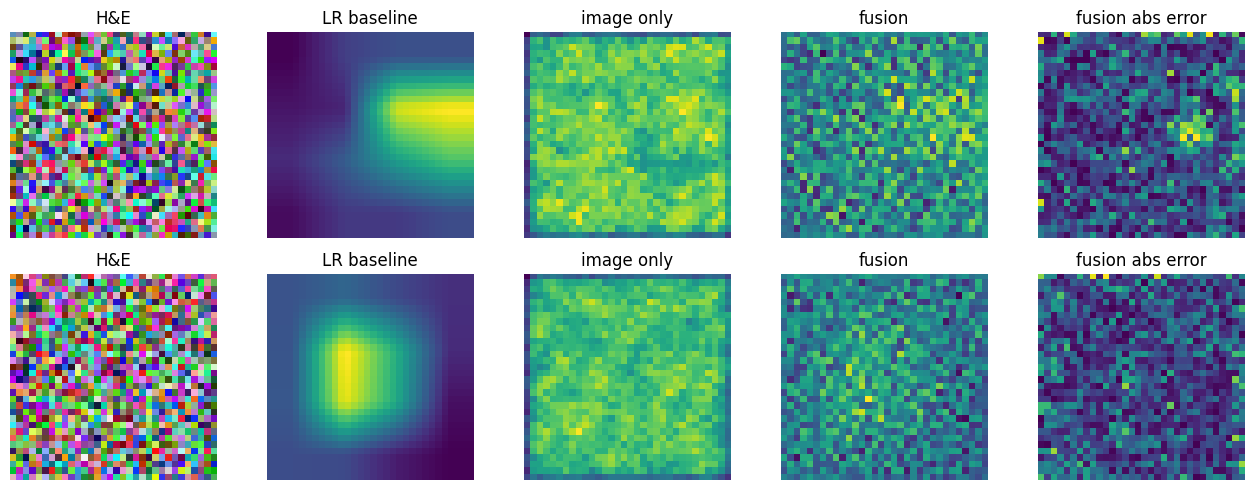

In [5]:
fig,ax=plt.subplots(2,5,figsize=(13,5))
for r,k in enumerate(range(min(2,len(ids)))):
 ims=[np.moveaxis(he[ids[k]],0,-1),base[ids[k],0],p_img[k,0],p_fus[k,0],(p_fus[k,0]-y[k,0]).abs()];titles=['H&E','LR baseline','image only','fusion','fusion abs error']
 for a,im,t in zip(ax[r],ims,titles):a.imshow(im,cmap=None if t=='H&E' else 'viridis');a.set_title(t);a.axis('off')
plt.tight_layout();plt.savefig(OUT/'adv05_ablation.png',dpi=150);plt.show();json.dump(metrics,open(OUT/'adv05_result.json','w'),indent=2)


## 如何对应题目阅读本答案

- 数据格式和真实/演示模式：第 1 部分；
- `lr` 定义与插值基线：第 2 部分；
- image-only 与 fusion 消融：第 3 部分；
- MAE、相关性和聚合一致性：第 4 部分；
- 空间结果解释：第 5 部分。

其他合理方案可以使用图网络、Transformer、扩散模型或物理约束。参考答案没有证明推断结果达到单细胞测量精度，也不把清晰图像等同于真实分子图谱。

完整的示范研究说明见同目录 `项目05_参考设计报告.md`。其中包括研究问题、数据独立性、文献依据、方法选择、评价、结果解释、局限、下一步实验和本包运行记录。它仍然只是一种参考方案。